# EE4309 Object Detectation Project - Google Colab Version

This notebook maintains the same experience as the local Makefile commands, allowing you to easily run the project on Colab.

## 📝 Important Notes
1. **Enable GPU**: Click `Runtime` → `Change runtime type` → Select `T4 GPU`
2. **Run Order**: Please run cells in sequence
3. **Command Mapping**: Each cell corresponds to a make command

## 🔧 Step 0: Clone Project and Enter Directory

In [ ]:
!git clone https://github.com/ElectricPyramid/EE4309_Project.git
%cd EE4309_Project
!pwd

/home/mohamed/EE4309/EE4309_Project
/home/mohamed/EE4309/EE4309_Project


/home/mohamed/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## 📦 Step 1: Setup (equivalent to `make setup`)

In [ ]:
# Install project dependencies (equivalent to make setup)
%pip install -r requirements.txt

# Verify environment
import torch
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 📋 Help (equivalent to `make help`)

In [4]:
# Show all available commands (equivalent to make help)
!make help

EE4309 ObjDet Project
Usage: make <target>

check                Run all checks
clean                Clean up runs directory
eval                 Evaluate the model (override WEIGHTS=... MODEL=...)
format               Format code
help                 Show this help message
infer                Run inference (override INPUT=... MODEL=...; run 'make samples' first)
lint                 Run code linting
samples              Download sample images for inference testing
setup                Install dependencies and setup the project in editable mode
submit               Create a submission
test                 Run tests
train                Train the model (override MODEL=resnet50 etc.)


## 🖼️ Step 2: Download Samples (equivalent to `make samples`)

In [7]:
# Download sample images (equivalent to make samples)
!make samples

bash scripts/download.sh
📥 Downloading sample images to data/sample_images
1. Downloading image with person...
2. Downloading image with dog...
3. Downloading image with horses...
4. Downloading image with eagle...

📊 Download results:
✅ Successfully downloaded 4 sample images
📁 Image list:
-rw-rw-r-- 1 mohamed mohamed 160K Oct 24 12:01  data/sample_images/dog.jpg
-rw-rw-r-- 1 mohamed mohamed 139K Oct 24 12:01  data/sample_images/eagle.jpg
-rw-rw-r-- 1 mohamed mohamed 131K Oct 24 12:01  data/sample_images/horses.jpg
-rw-rw-r-- 1 mohamed mohamed 112K Oct 24 12:01  data/sample_images/person.jpg

🚀 Now you can run inference test:
   bash scripts/infer.sh runs/frcnn_r50fpn_voc07/best.pt data/sample_images/

💡 Tips:
1. You can also copy your own images to data/sample_images directory
2. Supported formats: jpg, jpeg, png
3. Images should preferably contain objects from VOC dataset's 20 classes


## 🚀 Step 3: Train Model (equivalent to `make train`)


Main improvement here is the use of a warm up and coside decay for the learning rate. The learning rate schedule used (in train.py) combines a short warm-up phase (two epochs) followed by a cosine decay. During the first two epochs, the learning rate increases linearly from a small value to the base rate (0.02 or 0.05) to help stabilize early training. After the warm-up period, the schedule transitions into a cosine decay function, where the learning rate smoothly decreases from its maximum value toward zero as training progresses. This approach prevents abrupt changes in the learning rate and a smoother convergence. I saw an improvement in the models mAP both early on and in the later stages (compared to not using it). 


In [ ]:
# Standard training (equivalent to make train)
# model choices: "reset50", "vit"

import torch, gc
gc.collect()
torch.cuda.empty_cache()
#BEST PARAMETERS FOR ViT
%cd /content/EE4309_Project
!PYTHONPATH=$PYTHONPATH:/content/EE4309_Project python3 src/engine/train.py --train-set trainval --val-set trainval --epochs 30 --batch-size 4 --lr 0.02 --num-workers 16 --model "vit"

bash scripts/train.sh "runs/reset50_voc07" "20" "1" "reset50"
🚀 Starting training...
Model: reset50
Output directory: runs/reset50_voc07
Epochs: 20
Batch size: 1

📊 Dataset configuration:
- Dataset: trainval (PASCAL VOC 2007)
- Train samples: 2000 (from index 0-1999)
- Val samples: 500 (from index 2000-2499)
- Test set: reserved for final evaluation

Traceback (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/mohamed/EE4309/EE4309_proj/src/engine/train.py", line 14, in <module>
    from src.datasets.voc import VOCDataset, collate_fn
  File "/home/mohamed/EE4309/EE4309_proj/src/datasets/voc.py", line 5, in <module>
    import deeplake
ModuleNotFoundError: No module named 'deeplake'
make: *** [Makefile:33: train] Error 1


In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()
#BEST PARAMETERS FOR resnet50
%cd /content/EE4309_Project
!PYTHONPATH=$PYTHONPATH:/content/EE4309_Project python3 src/engine/train.py --train-set trainval --val-set trainval --epochs 30 --batch-size 2 --lr 0.05 --num-workers 16 --model "resnet50"

## 📊 Step 4: Evaluate Model (equivalent to `make eval`)

In [ ]:
# Evaluate the model (equivalent to make eval)
!make eval

## 🔍 Step 5: Run Inference (equivalent to `make infer`)

In [ ]:
# Run inference (equivalent to make infer)
!make infer

---

## 📊Plot mAP & Loss vs Epochs
From the logs.json file directly

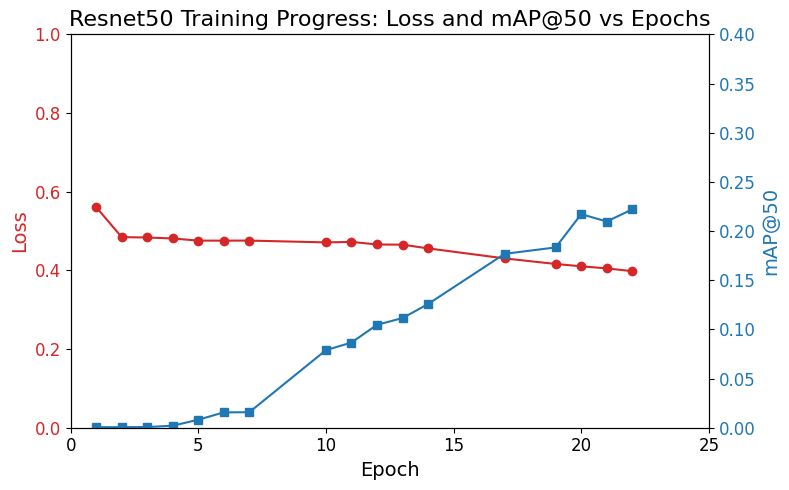

In [ ]:
import json
import matplotlib.pyplot as plt

def plot_training_log(log_file, x_range=None, loss_range=None, map_range=None):
    epochs, losses, maps = [], [], []

    # Read JSONL log file (one JSON per line)
    with open(log_file, "r") as f:
        for line in f:
            if not line.strip():
                continue
            data = json.loads(line)
            epochs.append(data["epoch"])
            losses.append(data["loss"])
            maps.append(data["map50"])

    # Plot both curves
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.set_xlim(-1, max(epochs)+1)


    # Loss curve (left y-axis)
    color = 'tab:red'
    ax1.set_xlabel('Epoch', fontsize=14)
    ax1.set_ylabel('Loss', color=color, fontsize=14)
    ax1.plot(epochs, losses, color=color, marker='o', label='Loss')
    ax1.tick_params(axis='y', labelcolor=color, labelsize=12)
    ax1.tick_params(axis='x', labelsize=12)

    if x_range:
        ax1.set_xlim(x_range)
    if loss_range:
        ax1.set_ylim(loss_range)

    # mAP@50 curve (right y-axis)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('mAP@50', color=color, fontsize=14)
    ax2.plot(epochs, maps, color=color, marker='s', label='mAP@50')
    ax2.tick_params(axis='y', labelcolor=color, labelsize=12)

    if map_range:
        ax2.set_ylim(map_range)

    plt.title("Resnet50 Training Progress: Loss and mAP@50 vs Epochs", fontsize=16)
    fig.tight_layout()
    plt.show()

from pathlib import Path

home = Path.home()
log_path = home / "EE4309/Project_Results/RCNN_Run-Final/logs.jsonl"

# Set fixed axis ranges
plot_training_log(
    log_path,
    x_range=(0, 25),
    loss_range=(0, 1),
    map_range=(0, 0.4)
)

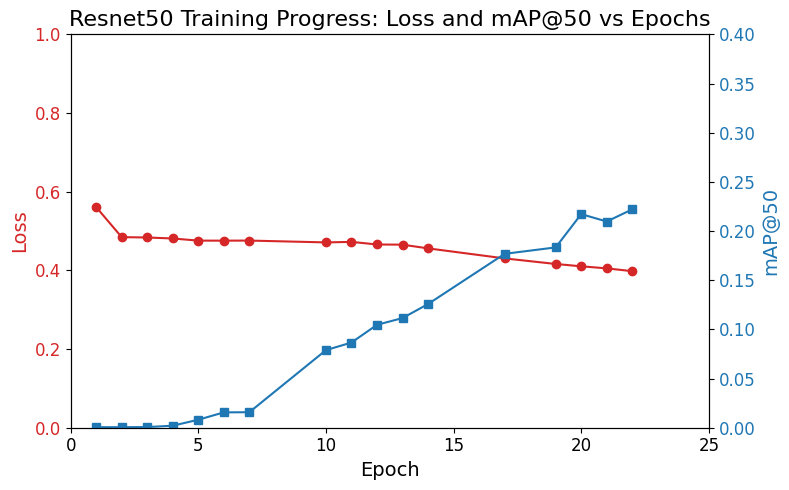

Results previously generated from running Resnet50 for 22 epochs, reaching mAP of 22.2% at the last epoch.

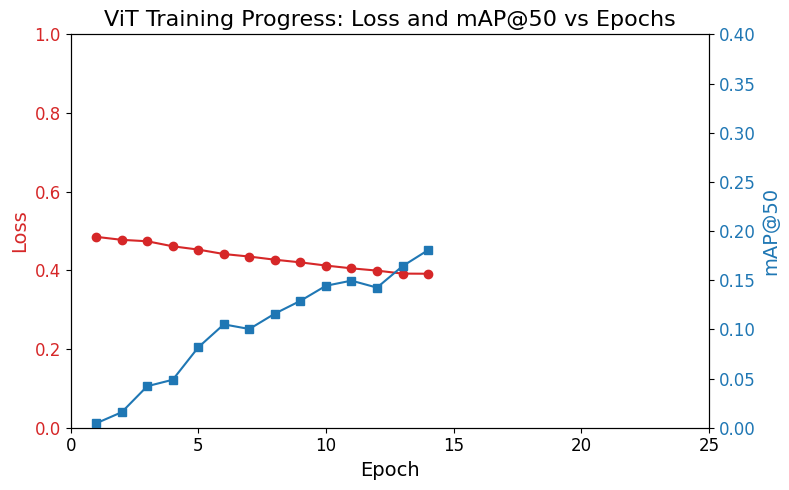

Results previously generated from running ViT for 14 epochs, reaching mAP of 18.1% at the last epoch.

The ViT model sees a higher mAP than the resnet50 model in the early epochs, this trend will not necessarily hold for more epochs.

---

## 💾 Extra: Save to Google Drive

In [ ]:
# Mount Google Drive to save training results
from google.colab import drive
drive.mount('/content/drive')

# Create save directory
!mkdir -p /content/drive/MyDrive/EE4309_results

# Copy training results
!cp -r runs/* /content/drive/MyDrive/EE4309_results/
print("✅ Results saved to Google Drive!")

## 📝 Submit Your Work (equivalent to `make submit`)

**Important**: This will create a git commit with your student information

In [ ]:
# Submit your work with student information (equivalent to make submit)
# You will be prompted to enter:
# - Your full name
# - Your student ID (format: A0123456X)
# - Optional additional message
# Please run this command before compressing and submitting your project.
!make submit

## 📈 Visualize Inference Results

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Detection result images to display
detection_images = [
    'runs/infer_vis/dog_det.jpg',
    'runs/infer_vis/eagle_det.jpg', 
    'runs/infer_vis/horses_det.jpg',
    'runs/infer_vis/person_det.jpg'
]

# Check which images exist
existing_images = [img for img in detection_images if os.path.exists(img)]

if len(existing_images) >= 4:
    print("Displaying inference detection results:")
    
    # Create 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Object Detection Results', fontsize=16, fontweight='bold')
    
    # Flatten axes for easy iteration
    axes_flat = axes.flatten()
    
    for i, img_path in enumerate(existing_images[:4]):
        try:
            img = mpimg.imread(img_path)
            axes_flat[i].imshow(img)
            # Extract image name without extension for title
            img_name = os.path.basename(img_path).replace('_det.jpg', '')
            axes_flat[i].set_title(img_name.title(), fontsize=14)
            axes_flat[i].axis('off')
        except Exception as e:
            axes_flat[i].text(0.5, 0.5, f'Error loading\n{os.path.basename(img_path)}', 
                            ha='center', va='center', transform=axes_flat[i].transAxes)
            axes_flat[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
elif len(existing_images) > 0:
    print(f"Found {len(existing_images)} detection results:")
    
    # Calculate grid size for available images
    n_images = len(existing_images)
    n_cols = min(2, n_images)
    n_rows = (n_images + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 6*n_rows))
    fig.suptitle('Available Detection Results', fontsize=16, fontweight='bold')
    
    # Handle single image case
    if n_images == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if hasattr(axes, '__iter__') else [axes]
    else:
        axes = axes.flatten()
    
    for i, img_path in enumerate(existing_images):
        try:
            img = mpimg.imread(img_path)
            axes[i].imshow(img)
            img_name = os.path.basename(img_path).replace('_det.jpg', '')
            axes[i].set_title(img_name.title(), fontsize=14)
            axes[i].axis('off')
        except Exception as e:
            axes[i].text(0.5, 0.5, f'Error loading\n{os.path.basename(img_path)}', 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].axis('off')
    
    # Hide empty subplots
    for i in range(n_images, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ No detection result images found.")
    print("Please run inference first:")
    print("!make infer")

## 📊 Check Git History (View Submission Records)

In [ ]:
# View git commit history to check submissions
!git log --oneline -n 5

In [ ]:
# View detailed changes in the last commit
!git diff HEAD~1 --stat

## ⚠️ Troubleshooting

### 1. GPU Out of Memory
```bash
# Reduce batch size
!bash scripts/train.sh --batch-size 64 --epochs 20
```

### 2. Runtime Limits
- Colab free tier has ~12 hour limit
- Use checkpoint feature to train in segments
- Save to Google Drive regularly

### 3. Disconnection Issues
- Use resume training feature above to continue
- Consider Colab Pro for longer runtime

### 4. Submission Issues
- Make sure you run `make submit` before the deadline
- Use `git log` to verify your submission was recorded
- Your instructor can use `git diff` to review your changes